# Clustering: K-means example with iris with exercises

*Alípio Jorge, January 2021, based on different examples from sklearn documentation*

We will use k-means on the Iris data set. The idea of using kmeans on this very old and easy dataset is that we know what the results should look like, even if we are not botanicists.

We will:
- Use PCA to visualize the 4d data in 2d
- Look at the data with labels and see the three groups (classes)
- Look at the data without labels and see that the number of clusters is not obvious
- Run kmeans with different values of $k$
- Check the cluster tendency (is the dataset clusterable?) using the Hopkins statistic
- Look at extrinsic clustering quality measures
- Look at intrinsic clustering quality measures
- Use the elbow technique on inertia (within cluster error) for deciding the number of clusters (pretending we do not know they are three)
- Use the Silhouette Coeficient to see the quality of the clusters for different values of $k$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn import datasets

np.random.seed(5)

iris = datasets.load_iris()
X = iris.data
y = iris.target #  y: As labels reais do dataset Iris (a espécie verdadeira de cada flor, que são 3 classes: 0, 1, ou 2).

print(y)
X[0:5,:]

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

## The ground truth

Iris is a labeled data set. This is not the typical scenario in clustering. But with labelled data we can evaluate better what clustering is doing (and what it should do).

> Nota sobre PCA (Principal Component Analysis):
> * O **PCA (Principal Component Analysis)** é uma técnica de redução de dimensionalidade.
>    * O  objetivo é pegar num dataset com muitas colunas (muitas "dimensões" ou "features") e transformá-lo num novo dataset com menos colunas (novas dimensões chamadas "Componentes Principais").
>    * O PCA faz isto de forma inteligente: ele encontra as novas "direções" (os componentes) que capturam a maior quantidade de informação (variância) dos dados originais.
>        * O **Componente 1 (eixo X do gráfico)** é a nova dimensão que, sozinha, **explica a maior parte do "espalhamento" dos dados**.
>        * O **Componente 2 (eixo Y do gráfico)** é a **segunda melhor dimensão (perpendicular à primeira) que explica a maior parte da variação restante**.

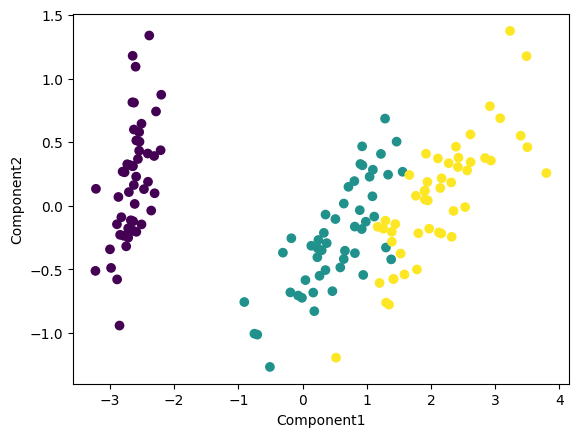

In [34]:
# Visualize the examples in 2D busing PCA - Principal Components Analysis

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
xpto=PCA(n_components=2)
red_X = PCA(n_components=2).fit_transform(X)


plt.scatter(red_X[:,0],red_X[:,1],c=y)

plt.xlabel('Component1')
plt.ylabel('Component2')

plt.show()


> Do gráfico acima podemos concluir que:
> * **Conclusão principal** é que as 3 espécies de flores de Iris são muito distintas umas das outras e que esta distinção é capturada mesmo depois de **aplicar o PCA e "esmagar" os dados de 4 dimensões para apenas 2**.

## 2 clusters or 3 clusters?

Now imagine you are the botanicist that first studied these species. How many species would you propose for a start? If we plot without labels we observe 2 clusters. 3 clusters are possible (or more) but not very obvious.

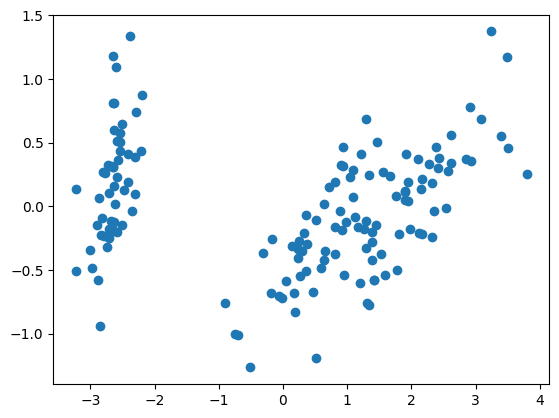

In [4]:
plt.scatter(red_X[:,0],red_X[:,1])

## What is the result with 2 clusters?

We run kmeans for 2 clusters and plot the results.

In [5]:
kmeans = KMeans(n_clusters=2,random_state=1)
kmeans.fit(X)
kmeans.labels_ # As etiquetas labels pelo algoritmo K-Means (o cluster ao qual o K-Means atribuiu cada flor, que são 2 clusters: 0 ou 1

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

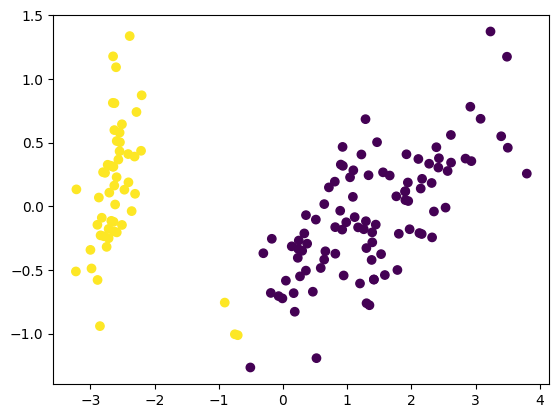

In [6]:
plt.scatter(red_X[:,0],red_X[:,1],c=kmeans.labels_)

## What is the result with 3 clusters?

We run kmeans for 3 clusters and plot the results. You can try with 4, 5 and 6 clusters.

**Exercises:**
- see the results with different values of $k$
- build a multiplot using subplot that shows the result with different cluster numbers.

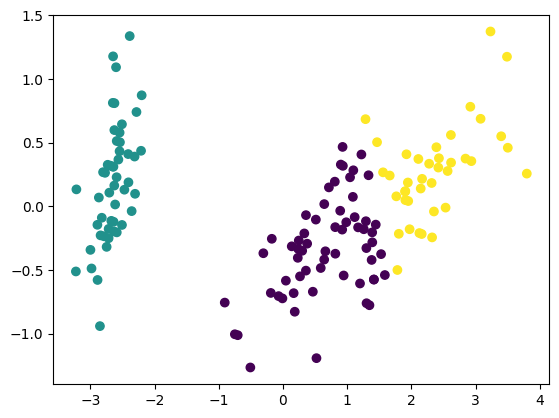

In [7]:
kmeans = KMeans(n_clusters=3,random_state=1)
kmeans.fit(X)
kmeans.labels_
plt.scatter(red_X[:,0],red_X[:,1],c=kmeans.labels_)

Axes(0.125,0.712609;0.775x0.167391)
Axes(0.125,0.511739;0.775x0.167391)
Axes(0.125,0.31087;0.775x0.167391)
Axes(0.125,0.11;0.775x0.167391)


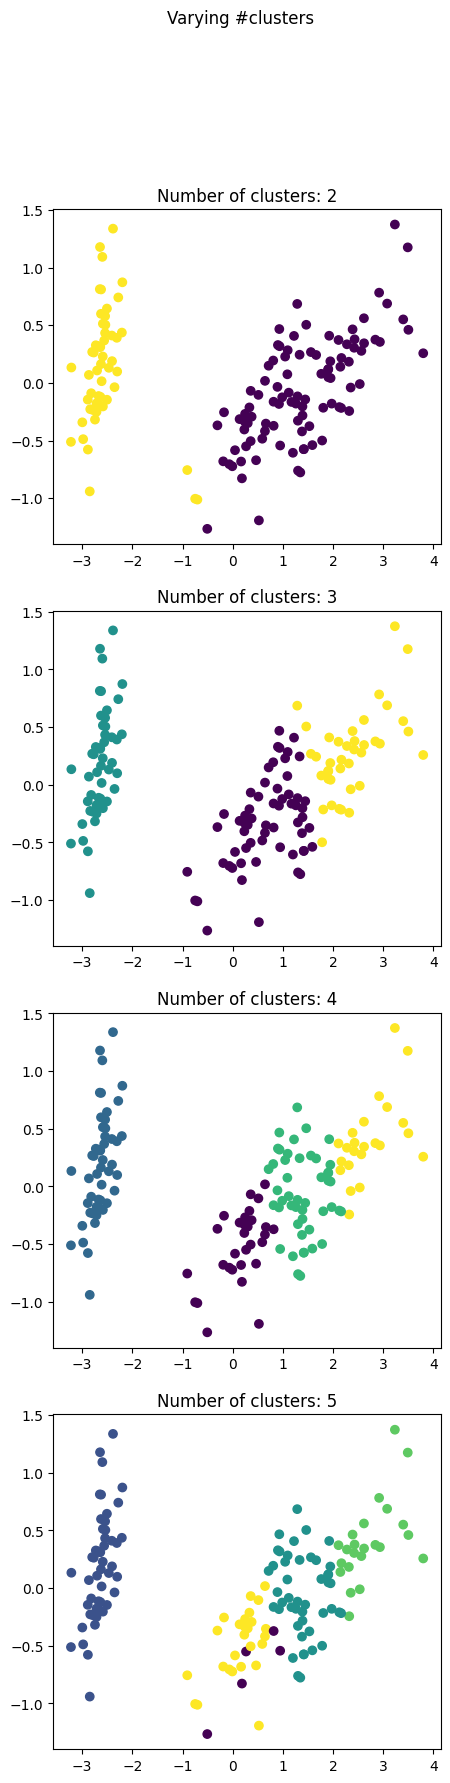

In [16]:
n = 4
k = 6
fig, axs = plt.subplots(n)

fig.set_figheight(20)
fig.set_figwidth(5)
fig.suptitle('Varying #clusters')

for i in range(2,k):
  print(axs[i-2])
  kmeans = KMeans(n_clusters=i,random_state=1)
  kmeans.fit(X)
  kmeans.labels_
  axs[i-2].set_title("Number of clusters: " + str(i))
  axs[i-2].scatter(red_X[:,0],red_X[:,1],c=kmeans.labels_)

Trying other hyper-parameters.
- Initial points can be random or chosen in a smarter way with 'k-means++' option. In this data set we do not see any difference but it may be visible in scenarios where clusters are more overlaped.

**Exercise**: take a look at the other hyperparameters of kmeans and try them on this data. See if they make a difference.

4

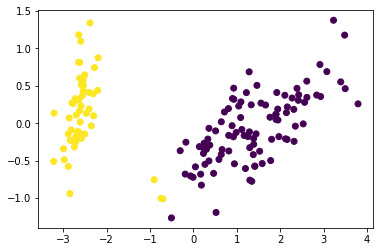

In [ ]:
kmeans = KMeans(init='k-means++',n_clusters=2,random_state=4)
kmeans.fit(X)
kmeans.labels_
plt.scatter(red_X[:,0],red_X[:,1],c=kmeans.labels_)
kmeans.n_iter_

## Cluster tendency

We can use an implementation for Hopkins statistic. You may have install `pyclustertend` first in your python environment using conda or pip.

This Hopkins implementation has the opposite orientation of the one described in class. Closer to zero means more clusterable.

**Exercise**: using a random number generator, generate 150 points with uniform distribution and measure the Hokins coefficient on those points. What should the value be?

In [19]:
#from pyclustertend import hopkins
#from sklearn.preprocessing import scale
# in this implementation hopkins values closer to 0 mean clusterable
#hopkins(scale(X),150)

## Extrinsic Measures of quality

Extrinsic measures of quality are possible because we know the labels in this case. As said before, in the real world we typically do not have labels for our data before clustering.

**Exercise**:
- Look for the precise definition of the metrics and try to understand what they do.
- Plot a curve for each metric along different values of $k$ from 1 to 10. Where is the peak?

In [10]:
from sklearn import metrics

clustering_metrics = [
    ('homog',metrics.homogeneity_score), # Mede se cada cluster contém apenas membros de uma única classe real. Uma pontuação de 1.0 significa que todos os clusters são perfeitamente "puros".
    ('complet',metrics.completeness_score), # Mede se todos os membros de uma determinada classe real são atribuídos ao mesmo cluster. Uma pontuação de 1.0 significa que todas as flores da mesma espécie estão no mesmo cluster.
    ('v_meas',metrics.v_measure_score), # É a média harmónica (um tipo de média) da homogeneidade e da completude. Dá-lhe uma pontuação única que equilibra as duas.
    ('adjust_rand',metrics.adjusted_rand_score), # Mede a semelhança entre as labels reais e as previstas, corrigindo para atribuições feitas ao acaso. Uma pontuação de 1.0 é uma correspondência perfeita, e 0.0 é o esperado por pura sorte.
    ('mutual_info',metrics.adjusted_mutual_info_score), # Outra métrica que mede a concordância entre as duas conjuntos de etiquetas, também ajustada para o acaso.
]


In [11]:
kmeans = KMeans(init='k-means++',n_clusters=2,random_state=4)
kmeans.fit(X)
kmeans.labels_ # As etiquetas previstas pelo algoritmo K-Means (o cluster ao qual o K-Means atribuiu cada flor, que são 2 clusters: 0 ou 1).

for (name,m) in clustering_metrics:
    print(name,m(y, kmeans.labels_) )

homog 0.5223224641010155
complet 0.8835142349190769
v_meas 0.6565191143081123
adjust_rand 0.5399218294207123
mutual_info 0.6538380713762776


homog 0.0
complet 1.0
v_meas 0.0
adjust_rand 0.0
mutual_info 0.0
homog 0.5223224641010155
complet 0.8835142349190769
v_meas 0.6565191143081123
adjust_rand 0.5399218294207123
mutual_info 0.6538380713762776
homog 0.7364192881252849
complet 0.7474865805095324
v_meas 0.7419116631817836
adjust_rand 0.7163421126838476
mutual_info 0.7386548254402864
homog 0.736419288125285
complet 0.6171211011982414
v_meas 0.6715128497327386
adjust_rand 0.5744686546766138
mutual_info 0.6658098609744905
homog 0.8083138423637096
complet 0.558434692665354
v_meas 0.6605318836181241
adjust_rand 0.49478421932222
mutual_info 0.6534515091101931
homog 0.8309376027605745
complet 0.5228596393917885
v_meas 0.6418446157354109
adjust_rand 0.45507224888954784
mutual_info 0.6328880142346159
homog 0.8309376027605745
complet 0.5003330642521018
v_meas 0.6245845676513134
adjust_rand 0.4317071160804106
mutual_info 0.6132143702752707
homog 0.8478714541121889
complet 0.47814570209917423
v_meas 0.6114643235455995
adjust_rand 0.40143

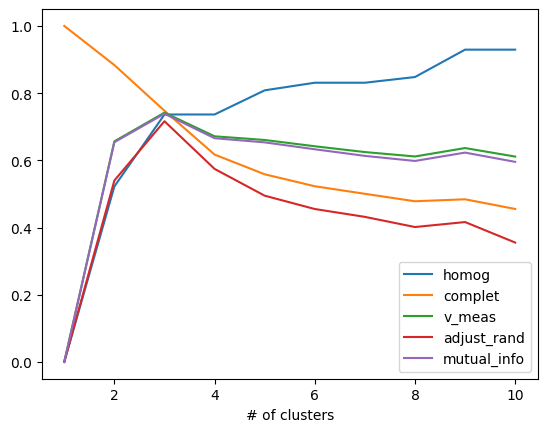

In [23]:
n = 11
l = np.zeros((10,5))
names = ["homog","complet","v_meas","adjust_rand","mutual_info"]
for i in range(1,n):
  kmeans = KMeans(init='k-means++',n_clusters=i,random_state=4)
  kmeans.fit(X)
  kmeans.labels_
  met = []
  names = []
  for (name,m) in clustering_metrics:
     print(name,m(y, kmeans.labels_) )
     met.append(m(y, kmeans.labels_))
  l[i-1] = np.array(met,float)
print(l)
for i in range(5):
  (name,m) = clustering_metrics[i]
  plt.plot(np.array([1,2,3,4,5,6,7,8,9,10],int),l[:,i],label=name);
print(l[0,2])
plt.xlabel('# of clusters')
plt.legend()
plt.show()

> Observações sobre a figura acima
> 1) A conclusão mais importante do gráfico é que k=3 é o número ótimo de clusters para este dataset.
>2) O Pico em k=3: Repapar como as linhas verde (v_meas), vermelha (adjust_rand) e roxa (mutual_info) atingem o seu valor máximo absoluto exatamente quando o Eixo X (# of clusters) é 3.
    * Estas três métricas são métricas "completas" que tentam equilibrar diferentes aspetos da qualidade do clustering.
    * O facto de todas elas concordarem que k=3 é o melhor resultado é um indicador muito forte.

>3) A História de homog vs. complet:
    * As linhas azul e laranja contam uma história interessante que explica porquê 3 é o ponto ótimo:
        * complet (laranja): Começa em 1.0 para k=1 (o que é lógico: se só há um cluster, ele "contém" de forma completa todos os membros de todas as classes). À medida que aumentamos os clusters, esta métrica desce. Porquê? Porque quando k > 3, o K-Means é forçado a dividir uma classe real (ex: dividir a espécie "Versicolor" em dois clusters diferentes). Isto quebra a "completude".
        * homog (azul): Esta métrica sobe quase continuamente. Porquê? Porque se tivermos muitos clusters (ex: k=10), o K-Means pode criar clusters muito pequenos e "puros". Por exemplo, pode criar 3 clusters diferentes que contêm apenas flores da espécie "Setosa". Cada um desses clusters é 100% homogéneo, aumentando a média geral.
>4) O "Ponto de Equilíbrio": O valor k=3 é o "ponto de equilíbrio" (o trade-off perfeito).
    * É o ponto onde as linhas homog e complet se cruzam. A métrica v_meas (verde) é a média harmónica destas duas, e é por isso que ela atinge o seu pico exatamente neste ponto de cruzamento.

# Intrinsic measures of quality

Inertia is the within-cluster variability and can be used to measure how points are close to each other in the same cluster. This is maximal with $k=n$. How can we find a non-trivial value for $k$?

**Exercise:** Check the definition of inertia in sklearn documentation.

In [ ]:
kmeans = KMeans(init='k-means++',n_clusters=3,random_state=4)
kmeans.fit(X)
kmeans.inertia_

78.85144142614601

### The elbow

Let us try the elbow approach.

**Exercise**: run with different starting points. Does the elbow change a lot?

>*  A **inércia** é a métrica usada no famoso "Método do Cotovelo" para ajudar a escolher o **número ideal de clusters (k)**.
> * A inércia **diminui à medida que aumentamos o número de clusters** (n_clusters).
>* **Se tivermos tantos clusters quanto pontos de dados**, a **inércia será 0** (cada ponto é o seu próprio centróide), o que não é útil.
>* O "**cotovelo" é o ponto num gráfico (Inércia vs. Nº de Clusters) onde a inércia para de diminuir tão rapidamente.**
>    *  Esse **ponto é frequentemente considerado o valor k ideal**, pois **representa o melhor compromisso entre a compactação do cluster e o número de clusters**.

In [ ]:
results=[]
for k in range(1,10):
    kmeans = KMeans(n_clusters=k,random_state=4)
    kmeans.fit(X)
    results+=[kmeans.inertia_]
results

[681.3706,
 152.34795176035792,
 78.85144142614601,
 57.228473214285714,
 46.472230158730156,
 39.054977867477874,
 34.299712121212124,
 30.33777154862682,
 28.208283633033638]

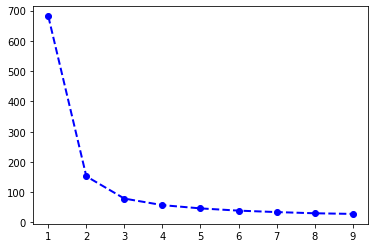

In [ ]:
plt.plot(range(1,10), results, 'bo--',linewidth=2, markersize=6)

The elbow is either 2 or 3. Hard to decide.

### Silhouette

What can we learn from the silhouette coefficient?

 **Exercise**:
 - Run the example with different values of $k$ and compare the average silhouette values and the silhouette plots.
 - Find the elbow for the silhouette coefficient.
 - Show the different silhouette plots (for $m$ different $k$s) on a 1xm panel using subplots.

>O que é a Métrica "Silhouette"?
> * A Métrica de Silhueta (Silhouette Score) é uma medida de quão bom é um clustering. Ao contrário das métricas do exercício anterior (como homogeneity), a silhueta não precisa das etiquetas reais (y) para funcionar. Ela avalia a qualidade do clustering usando apenas os dados (X) e as etiquetas que o K-Means gerou (kmeans.labels_).
> * A métrica calcula, para cada ponto de dados individual, uma pontuação (o "coeficiente de silhueta") que mede duas coisas:
>   1) Coesão (a): Quão perto está o ponto de todos os outros pontos no seu próprio cluster? (Queremos que esta distância seja pequena).
>   2) Separação (b): Quão longe está o ponto de todos os pontos do cluster vizinho mais próximo? (Queremos que esta distância seja grande).

> * A pontuação varia de -1 a +1:
>     * **+1**: O ponto está muito longe do cluster vizinho e muito perto do seu próprio cluster. (Clustering perfeito).
>     * **0**: O ponto está no limite, exatamente entre dois clusters. (Clustering ambíguo).
>     *  **-1**: O ponto está, em média, mais perto de um cluster vizinho do que do seu próprio cluster. (Provavelmente está no cluster errado).

#### Silhouette (k=4)

In [27]:
k=4

kmeans = KMeans(init='k-means++',n_clusters=k,random_state=4)
kmeans.fit(X)
sil_score=metrics.silhouette_score(X, kmeans.labels_,
                                 metric="euclidean", sample_size=300,)

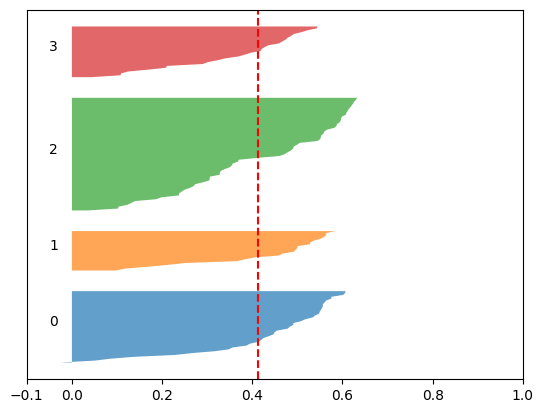

In [30]:
sample_silhouette_values = metrics.silhouette_samples(X, kmeans.labels_)

y_lower = 10
ax=plt.axes()
for i in range(k):
    # Aggregate the silhouette scores for samples belonging to
    # cluster i, and sort them
    cluster_labels=kmeans.labels_
    ith_cluster_silhouette_values = \
        sample_silhouette_values[cluster_labels == i]

    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    ax.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      alpha=0.7)

    # Label the silhouette plots with their cluster numbers at the middle
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples

ax.axvline(x=sil_score, color="red", linestyle="--")
ax.set_yticks([])  # Clear the yaxis labels / ticks
ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1]);


> Observações sobre a figura acima
> * **Eixo Y**: O eixo Y está dividido em secções, uma para cada cluster (neste caso, 0, 1, 2 e 3, porque k=4).
> * **Altura de cada secção (blob)**: A altura (ou espessura) de cada "lâmina" (blob) colorida representa o número de pontos (o tamanho) de cada cluster.
> * **Eixo X**: O eixo X é o coeficiente de silhueta (a pontuação de -1 a +1).
> * **Forma de cada secção**: Cada "lâmina" é um histograma. É composta por linhas horizontais, uma para cada ponto do cluster. O comprimento de cada linha é a pontuação de silhueta desse ponto. O código ordena-as (.sort()) da menor para a maior, o que dá esta forma de "lâmina" afunilada.
> * **Linha Vermelha Tracejada: Este é o sil_score (cerca de 0.42)**, que é a pontuação média de silhueta para todos os pontos no dataset.
>
> O que podemos concluir deste gráfico específico (para k=4)?
> * **Não há pontos mal classificados:** Nenhuma das lâminas (clusters) tem pontos que vão para o lado negativo (abaixo de 0). Isto é excelente e significa que nenhum ponto está claramente no cluster errado.
> * **Qualidade dos Clusters:** Os clusters 0 (azul) e 2 (verde) parecem ser os melhores. As suas "lâminas" são largas, e a grande maioria dos seus pontos ultrapassa a linha da média (a linha vermelha). O cluster 2, em particular, tem muitos pontos com pontuações altas (acima de 0.6).
> * **Os clusters 1 (laranja)** e 3 (vermelho) também são bons (todos os pontos são positivos), mas uma porção maior dos seus pontos está abaixo ou perto da média.
> * **Conclusão Geral:** O k=4 não é uma má escolha para este dataset. Produz 4 clusters razoavelmente bem separados. No entanto, se comparássemos este gráfico com o gráfico para k=3 (que sabemos ser o número "correto" de espécies), vemos abaixo que o gráfico para k=3 teria uma pontuação média (a linha vermelha) ainda mais alta e "lâminas" mais cheias e equilibradas.

#### Silhouette (k=3)

In [31]:
k=3

kmeans = KMeans(init='k-means++',n_clusters=k,random_state=4)
kmeans.fit(X)
sil_score=metrics.silhouette_score(X, kmeans.labels_,
                                 metric="euclidean", sample_size=300,)

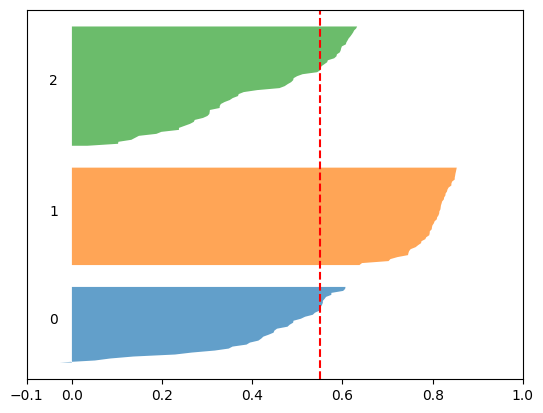

In [32]:
sample_silhouette_values = metrics.silhouette_samples(X, kmeans.labels_)

y_lower = 10
ax=plt.axes()
for i in range(k):
    # Aggregate the silhouette scores for samples belonging to
    # cluster i, and sort them
    cluster_labels=kmeans.labels_
    ith_cluster_silhouette_values = \
        sample_silhouette_values[cluster_labels == i]

    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    ax.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      alpha=0.7)

    # Label the silhouette plots with their cluster numbers at the middle
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples

ax.axvline(x=sil_score, color="red", linestyle="--")
ax.set_yticks([])  # Clear the yaxis labels / ticks
ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1]);
